# iADP pitch-step tracking on the nonlinear Boeing 737

A runnable B737 counterpart to the IHDP example, using the current iADP implementation
and an explicit pitch-to-rate outer loop. The notebook shows reference signals, physical
motion, online-learning diagnostics and step metrics. Text and plot labels are in English.

Algorithm source: [Konatala et al., AIAA 2024-2402](https://doi.org/10.2514/6.2024-2402).
This uses its incremental identification, critic and policy equations with **B737-specific
experimental tuning and a nominal-model warm start**; it does not reproduce the Citation II
flight-test setup or its model-free initialization.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tensoraerospace.benchmark import B737PitchStepBenchmark, ControlBenchmark
from tensoraerospace.agent.aa_indi import AircraftGeometry, FlightMeasurement
from tensoraerospace.aerospacemodel.b737.nonlinear import ElevatorEffectiveness

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.8, "savefig.bbox": "tight",
})


## 1. Trim, reference and nonlinear environment

The scenario follows [the IHDP B737 example](example_ihdp_nonlinear_b737.ipynb):
B737-800 configuration, 20,000 ft, 650 ft/s, 60 s, RK4 at 50 Hz, and a +1° pitch step at 15 s.
The initial 15 s are included in every full-flight plot. The step reference is shown explicitly.

The 12 states are body velocities `[u,v,w]` (ft/s), body rates `[p,q,r]` (rad/s),
Euler angles `[roll,pitch,yaw]` (rad), and NED position `[x,y,z]` (ft).
Virtual actions are **physical radians** `[elevator, aileron, rudder, throttle]`;
throttle is dimensionless. Aileron/rudder stay zero and throttle stays at trim.
These examples add a pitch-to-rate outer loop; its gain is separate from the adaptive inner loop.

This B737 runtime applies clipped surfaces with zero-order hold and has **no servo lag**.
Command slew limits below belong to the controllers. The B737-800 option scales geometry
and inertia while reusing the model's B737-100 aerodynamic tables. It is a simplified
cruise simulation, not a validated B737NG flight-test model.


Trim residual: 8.248e-11
Pitch: 2.0116 deg; elevator: -1.1747 deg; throttle: 0.4769
3000 transitions; 3001 state samples; final time 60.0 s


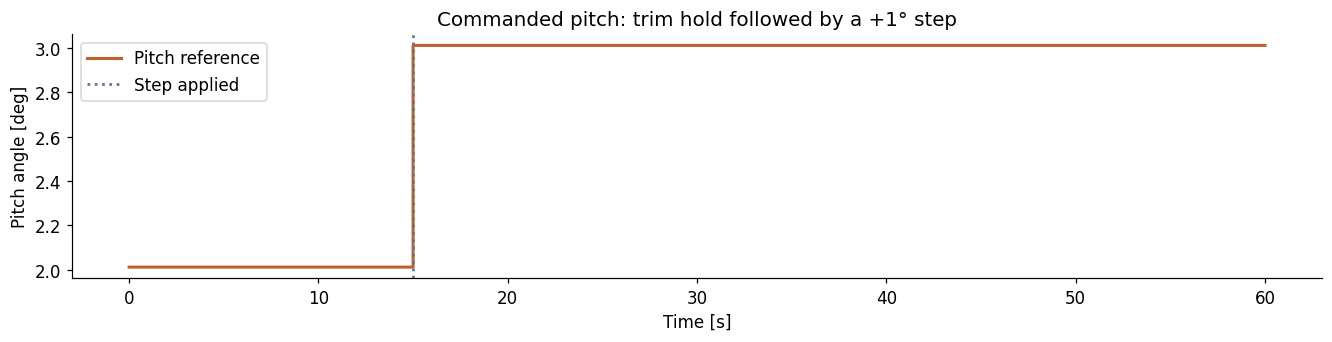

In [2]:
experiment = B737PitchStepBenchmark(duration=60.0, dt=0.02, step_time=15.0, step_deg=1.0)
env, trim_result, trim_action = experiment.make_env()
state, _ = env.reset(seed=experiment.seed)
params = env.unwrapped.model.param
theta_trim = trim_result.alpha_rad
reference = experiment.reference
OUTER_PITCH_GAIN = 0.8  # q_ref = gain * (theta_ref - theta), clipped to ±3 deg/s

print(f"Trim residual: {trim_result.residual:.3e}")
print(f"Pitch: {np.rad2deg(theta_trim):.4f} deg; "
      f"elevator: {np.rad2deg(trim_action[0]):.4f} deg; "
      f"throttle: {trim_action[3]:.4f}")
print(f"{experiment.steps} transitions; {experiment.steps + 1} state samples; "
      f"final time {experiment.time[-1]:.1f} s")
experiment.plot_reference(theta_trim)
plt.show()


## 2. Configure the adaptive rate controller

The iADP observation is `q` and its reference is the outer-loop command `q_ref`.
Control is **elevator deviation from trim in radians**; the environment receives trim plus
that deviation. The cost weights rate error and residual elevator: `q_error² + R*u_residual²`.
A one-state rate model omits angle-of-attack and speed dynamics; the full plant still integrates all 12 states.

We compute nominal `a = ∂q_dot/∂q`, `b = ∂q_dot/∂elevator` **once at trim**, initialize
`F` and `G` with the exact discretization of that scalar local model, and initialize the
quadratic critic with a discounted Riccati solution for `[q, q_ref]`.

Settings chosen for this example: `gamma=0.2`, `R=0.001`, 5 s of small open-loop
multisine excitation, a 20 s critic window and 5 Hz critic fitting. These differ from the
paper's experiment settings. The first fit occurs after a full closed-loop window, around
25 s. RLS and critic updates then continue throughout the episode. There is no blending,
regularization or positive-eigenvalue projection of the learned critic.


In [3]:
from scipy.linalg import solve_discrete_are
from tensoraerospace.agent.iadp import IADPAgent, IADPConfig

A_cont, B_cont = env.model.linearize(state, trim_action)
a, b = A_cont[4, 4], B_cont[4, 0]
A = np.diag([np.exp(a * experiment.dt), 1.0])
B = np.array([[b * np.expm1(a * experiment.dt) / a], [0.0]])
gamma = 0.2
R = np.array([[0.001]])
Q_augmented = np.array([[1.0, -1.0], [-1.0, 1.0]])
P_initial = solve_discrete_are(np.sqrt(gamma) * A, np.sqrt(gamma) * B, Q_augmented, R)
excitation_time = np.arange(round(5.0 / experiment.dt)) * experiment.dt
excitation = np.deg2rad(0.02) * (
    np.sin(2 * np.pi * 0.8 * excitation_time)
    + 0.5 * np.sin(2 * np.pi * 1.7 * excitation_time)
)[:, None]
agent = IADPAgent(1, 1, IADPConfig(
    dt=experiment.dt, Q=np.eye(1), R=R, gamma=gamma,
    gamma_rls=0.999, phi_init=1e3, F_init=A, G_init=B, P_init=P_initial,
    learning_mode="continuous", model_learning_only_steps=len(excitation),
    excitation_signal=excitation,
    policy_eval_window=round(20.0 / experiment.dt),
    policy_eval_min_samples=round(20.0 / experiment.dt),
    policy_eval_every=round(0.2 / experiment.dt),
    u_magnitude_limit=np.deg2rad(4.0), u_rate_limit=np.deg2rad(20.0),
))
print(f"Nominal q damping: {a:.6f} 1/s; elevator effectiveness: {b:.6f} 1/s²")
print(f"Initial discrete G_q: {B[0, 0]:.6f}; initial ||P||: {np.linalg.norm(P_initial):.6f}")


Nominal q damping: -0.545217 1/s; elevator effectiveness: -2.079609 1/s²
Initial discrete G_q: -0.041366; initial ||P||: 2.329707


## 3. Run all 3,000 plant transitions

The next rate reference is computed from the **next measured pitch** and the scheduled
pitch command, then supplied to `learn`. The applied elevator is read from the plant's
input history and converted back to the same trim-relative coordinate used by `predict`.
This keeps the critic cost and incremental identification consistent with the actual input.
A flight-envelope or horizon violation raises an error rather than scoring an incomplete run.


In [4]:
states, actions, rate_commands, learning = [state.copy()], [], [], []
critic_changes = 0
try:
    for k in range(experiment.steps):
        q_ref = float(np.clip(OUTER_PITCH_GAIN * (theta_trim + reference[k] - state[7]),
                              -np.deg2rad(3.0), np.deg2rad(3.0)))
        residual = agent.predict(state[4:5], np.array([q_ref]))
        action = trim_action.copy()
        action[0] += residual[0]
        action = np.clip(action, env.action_space.low, env.action_space.high)
        next_state, _, terminated, truncated, _ = env.step(action)
        applied = env.model.applied_action
        experiment.validate_transition(next_state, terminated, truncated, k)
        next_q_ref = float(np.clip(OUTER_PITCH_GAIN * (theta_trim + reference[k + 1] - next_state[7]),
                              -np.deg2rad(3.0), np.deg2rad(3.0)))
        previous_P = agent.P.copy()
        diagnostics = agent.learn(
            next_state[4:5], np.array([[q_ref, next_q_ref]]),
            applied_action=applied[:1] - trim_action[:1],
        )
        critic_changes += int(not np.array_equal(previous_P, agent.P))
        learning.append([
            np.linalg.norm(agent.P), np.linalg.eigvalsh(agent.P).min(),
            agent.G[0, 0], diagnostics["rls_pred_error_norm"],
        ])
        states.append(next_state.copy())
        actions.append(applied)
        rate_commands.append(q_ref)
        state = next_state
finally:
    env.close()
states, actions, rate_commands, learning = map(np.asarray, (states, actions, rate_commands, learning))
assert np.isfinite(learning).all()
assert agent.rls.num_updates == experiment.steps - 1
assert critic_changes > 0
print(f"Completed {experiment.duration:.1f} s; RLS updates: {agent.rls.num_updates}; "
      f"critic matrix changes: {critic_changes}; final phase: {agent.phase}")


Completed 60.0 s; RLS updates: 2999; critic matrix changes: 176; final phase: controller_training


## 4. Tracking, accumulated error and online learning

Both pitch and rate references are drawn explicitly. The cumulative error starts at the
pitch step and uses degrees × seconds. The nominal discrete `G_q` is shown only as a
trim reference, not as the true effectiveness along the changing trajectory.
The critic's smallest eigenvalue is logged without modifying it.


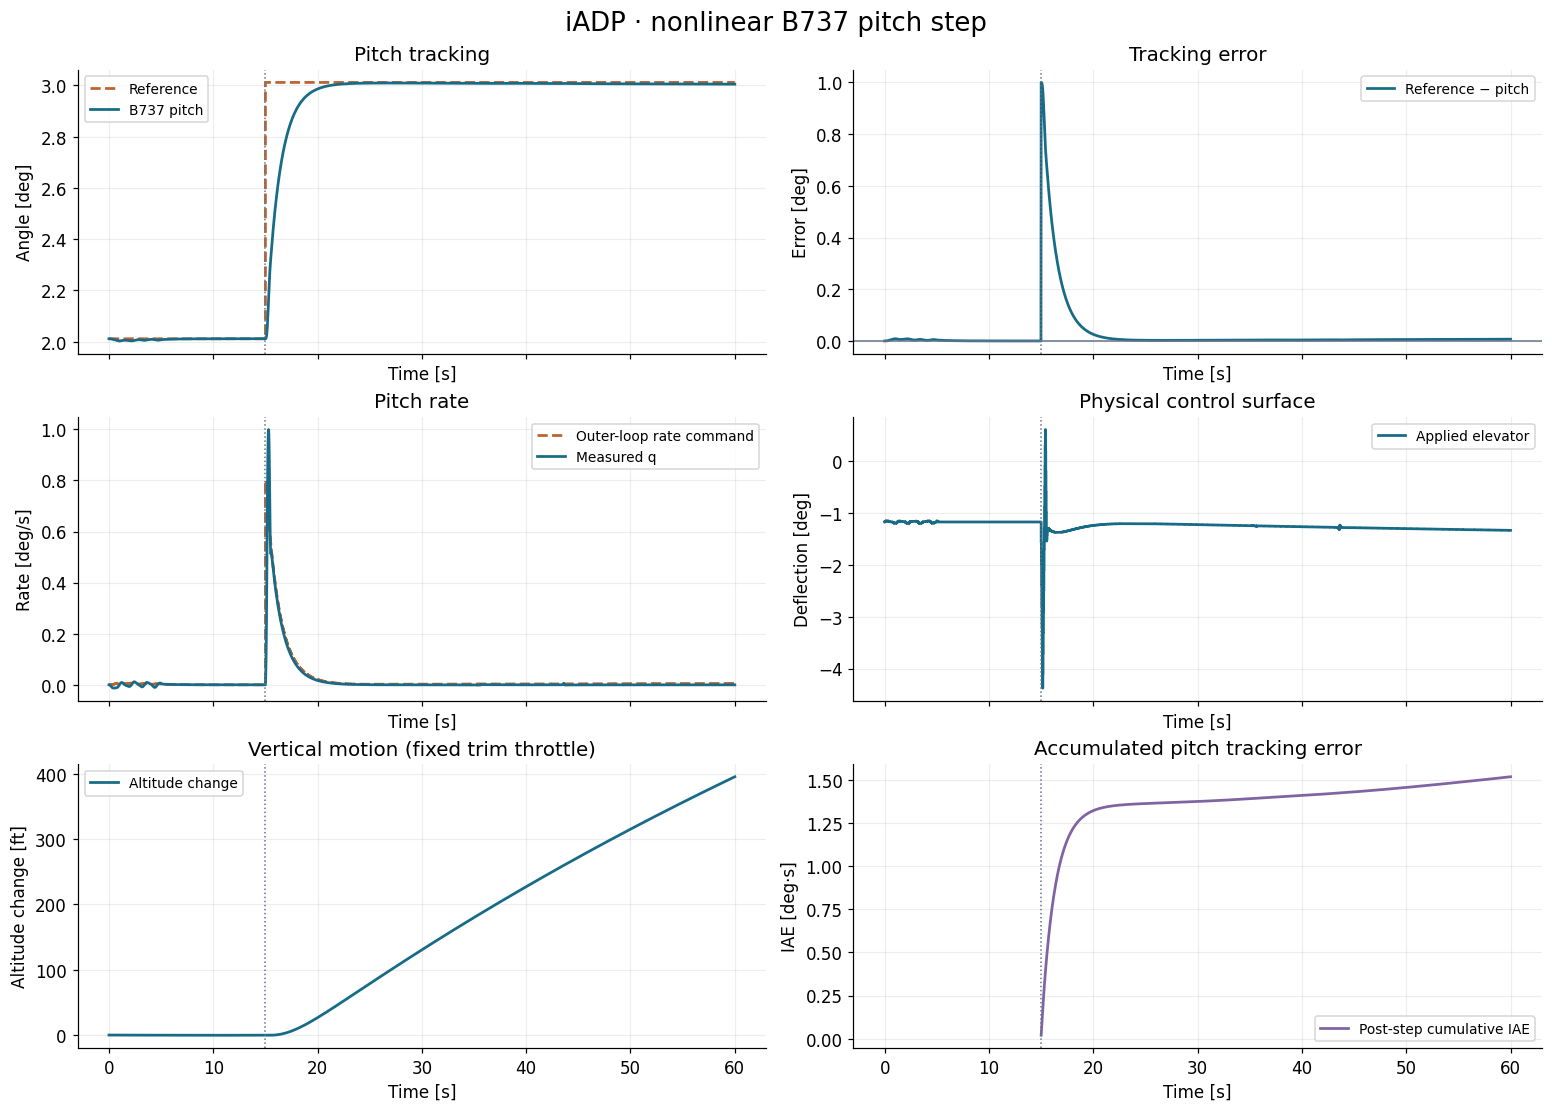

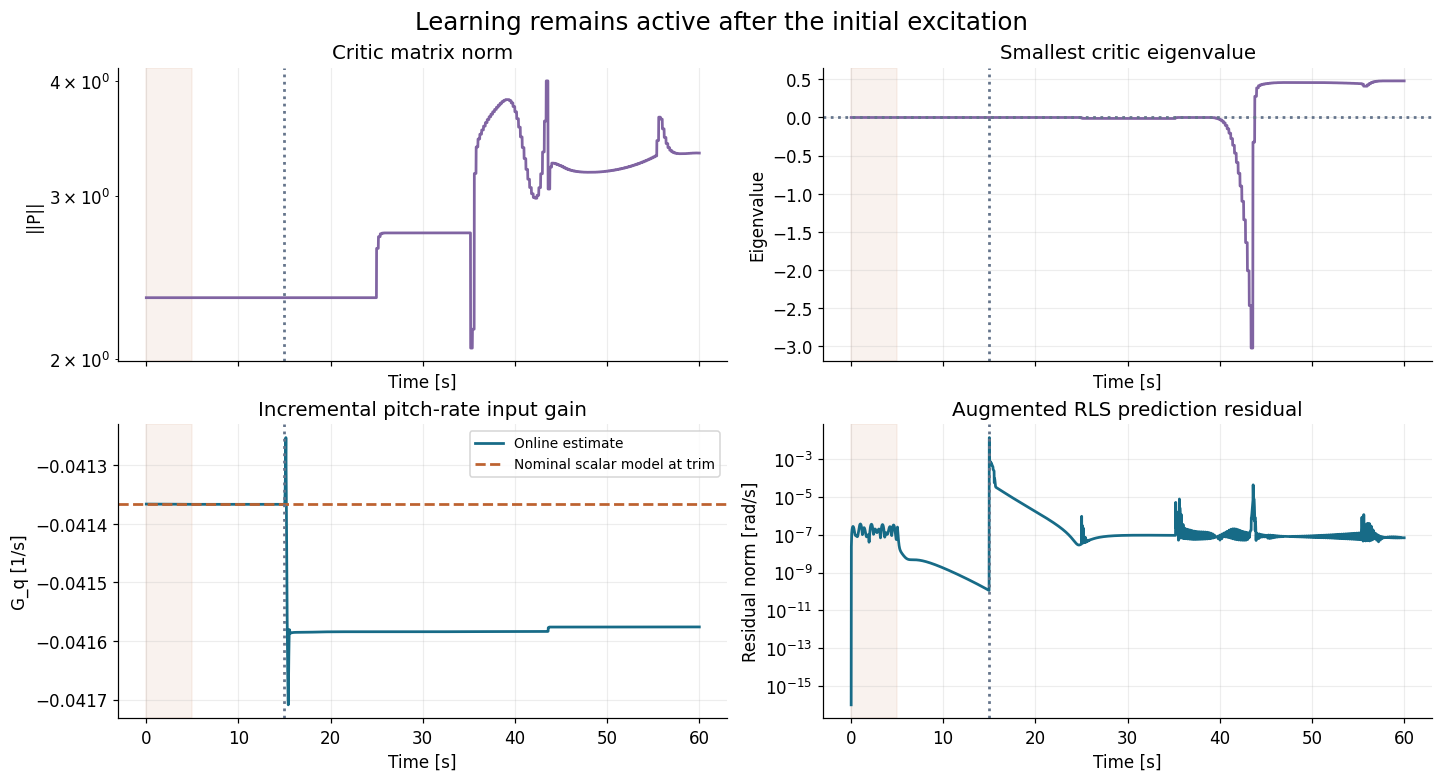

In [5]:
experiment.plot_response(states, actions, rate_commands, "iADP · nonlinear B737 pitch step")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, constrained_layout=True)
axes[0, 0].semilogy(experiment.time[1:], learning[:, 0], color="#8064a2")
axes[0, 0].set(title="Critic matrix norm", ylabel="||P||")
axes[0, 1].plot(experiment.time[1:], learning[:, 1], color="#8064a2")
axes[0, 1].axhline(0, color="#64748b", linestyle=":")
axes[0, 1].set(title="Smallest critic eigenvalue", ylabel="Eigenvalue")
axes[1, 0].plot(experiment.time[1:], learning[:, 2], label="Online estimate", color="#176b87")
axes[1, 0].axhline(B[0, 0], label="Nominal scalar model at trim", color="#bd6230", linestyle="--")
axes[1, 0].set(title="Incremental pitch-rate input gain", ylabel="G_q [1/s]")
axes[1, 0].legend(fontsize=9)
axes[1, 1].semilogy(experiment.time[1:], np.maximum(learning[:, 3], 1e-16), color="#176b87")
axes[1, 1].set(title="Augmented RLS prediction residual", ylabel="Residual norm [rad/s]")
for axis in axes.ravel():
    axis.axvspan(0, 5, alpha=0.08, color="#bd6230")
    axis.axvline(experiment.step_time, color="#64748b", linestyle=":")
    axis.set_xlabel("Time [s]")
    axis.grid(alpha=0.22)
fig.suptitle("Learning remains active after the initial excitation", fontsize=16)
plt.show()


## 5. Step-response assessment with `ControlBenchmark`

`evaluate_step` calls the repository's `ControlBenchmark.benchmarking_one_step` with
**pitch deviations in radians**, a zero pre-step baseline, and one second of pre-step data.
It refuses partial or non-finite trajectories. The table converts angle-based metrics to degrees.
Two windows distinguish the initial transient from later adaptation: the first 15 s after
the step, and the complete 45 s post-step interval.

The benchmark computes overshoot and its ±5% settling band relative to the **estimated
final output**, not the requested pitch. We report those native metrics unchanged and
add separately labelled overshoot/settling metrics relative to the **command**. Settling
requires staying in the corresponding band for the rest of the selected window.
The shaded plot uses the command band. Rise time is the **10–90% duration relative to
the estimated final output**, not a timestamp or a test of reaching the command.
Static error uses the benchmark's steady tail; the separate final error is a single sample.
IAE sums absolute pitch error times `dt` using the benchmark's rectangle rule; the
cumulative plot uses the same convention. ISE integrates squared error; ITAE additionally
weights elapsed time after the step. Rate-loop error is not added to angle error because their units differ.


,First 15 s after step,Full post-step interval
Overshoot vs. final output [%],0.03076,0.42909
"Settling around final output, 5% [s]",3.96000,3.86000
Overshoot vs. command [%],0.00000,0.00000
"Settling around command, 5% [s]",4.02000,4.02000
"Rise time, 10–90% [s]",2.76000,2.72000
Peak time [s],11.80000,11.80000
Static error [deg],0.00255,0.00649
IAE [deg·s],1.37486,1.51821
ISE [deg²·s],0.70844,0.70917
ITAE [deg·s²],1.98290,6.58719


,Measured result
Completed time [s],60.000000
Post-step pitch RMSE [deg],0.125508
Post-step pitch MAE [deg],0.033723
Final pitch error [deg],0.006817
Peak |q| [deg/s],0.999071
Peak |elevator| [deg],4.374588
Altitude change [ft],395.465330
Airspeed change [ft/s],-18.732700


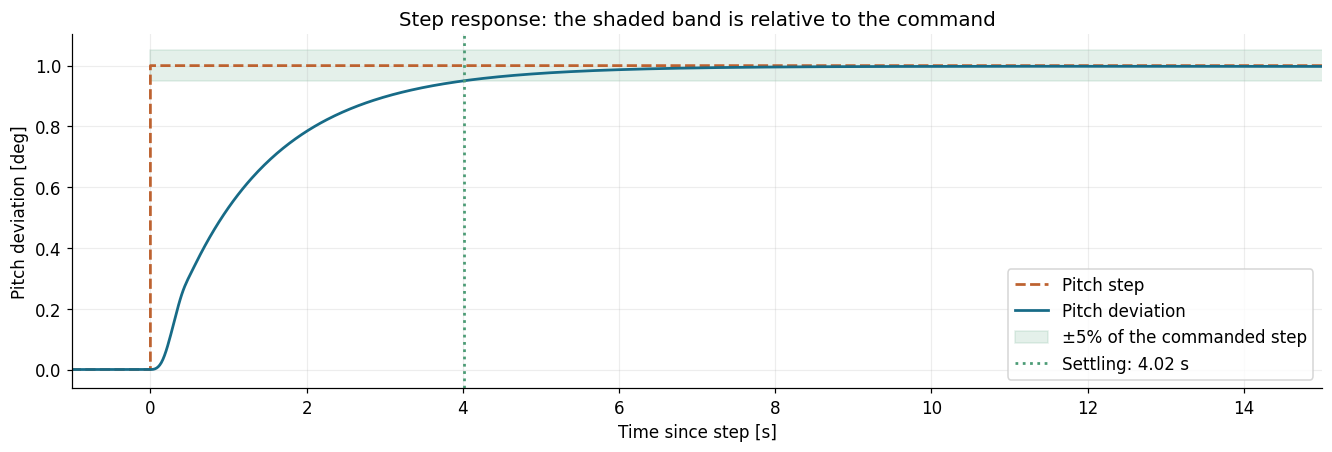

In [6]:
windows, physical_metrics = experiment.evaluate(states, actions)
display(experiment.metric_table(windows).style.format(precision=5, na_rep="Not reached"))
display(pd.Series(physical_metrics, name="Measured result").to_frame().style.format(precision=6))
experiment.plot_step(states, windows)
plt.show()


## 6. Interpretation

All curves and tables above are generated by the saved run. A full finite episode and
small tracking error support this **nominal, ideal-sensor, 60 s test only**; they do not
establish global stability or fault tolerance. No fault is injected and no policy is frozen.
The altitude increase and airspeed reduction are expected with a sustained nose-up command
and fixed throttle: this experiment controls pitch, not altitude or speed.

The public `tensoraerospace` API supplies model analysis, measurements and
benchmark metrics. This notebook only defines the application reference, agent
configuration and control loop; it does not depend on sibling examples.
